# Fish + KNeighborsTimeSeriesClassifier: untuned vs tuned comparison

This notebook runs the complete workflow for `KNeighborsTimeSeriesClassifier` on the `Fish` dataset:

1. untuned experiment using default KNN hyperparameters;
2. hyperparameter tuning for each `window_size × stride_ratio` configuration;
3. final retraining using the best saved hyperparameters;
4. Macro F1 comparison between untuned and tuned runs;
5. total execution-time comparison and per-configuration training-time plots.


## 1. Repository setup

The notebook automatically moves to the repository root, so it can be opened either from the root folder or from `notebooks/`.


In [1]:
from pathlib import Path
import os
import sys
import subprocess
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start_path: Path = Path.cwd()) -> Path:
    current = start_path.resolve()

    while current != current.parent:
        if (current / "scripts" / "run_experiment.py").exists():
            return current
        current = current.parent

    raise FileNotFoundError(
        "Could not find the repository root containing scripts/run_experiment.py"
    )


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())
assert Path("scripts/run_experiment.py").exists()


Working directory: /Users/gabbo/Documents/GitHub/Thesis_SlidingWindow


## 2. Experiment configuration

The window-size range is:

```text
10% → 50%, step 1%
```

The stride ratios are:

```text
0.1, 0.2, 0.5
```

For a quick smoke test, set `N_TRIALS = "2"`. For the complete experiment, use `N_TRIALS = "20"`.


In [2]:
DATASET_FOLDER = "data/raw/Fish"
CLASSIFIER = "KNeighborsTimeSeriesClassifier"

WINDOW_START = "0.10"
WINDOW_END = "0.50"
WINDOW_STEP = "0.01"

STRIDE_RATIOS = ["0.1", "0.2", "0.5"]

METRIC = "series_macro_f1"
N_TRIALS = "30"
RANDOM_STATE = "42"

NOT_TUNED_DIR = Path("results/Fish/noTuning/KNeighborsTimeSeriesClassifier/notTuned_10_50")
TUNING_DIR = Path("results/Fish/tuning/KNeighborsTimeSeriesClassifier/per_config_10_50")
TUNED_DIR = Path("results/Fish/tuned/KNeighborsTimeSeriesClassifier/tunedBest_10_50")

COMPARISON_DIR = Path("results/Fish/KNeighborsTimeSeriesClassifier/comparison_10_50")
PLOTS_DIR = Path("plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50")

for directory in [NOT_TUNED_DIR, TUNING_DIR, TUNED_DIR, COMPARISON_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_FOLDER)
print("Classifier:", CLASSIFIER)
print("Window range:", WINDOW_START, WINDOW_END, WINDOW_STEP)
print("Stride ratios:", STRIDE_RATIOS)
print("Metric:", METRIC)
print("N trials:", N_TRIALS)


Dataset: data/raw/Fish
Classifier: KNeighborsTimeSeriesClassifier
Window range: 0.10 0.50 0.01
Stride ratios: ['0.1', '0.2', '0.5']
Metric: series_macro_f1
N trials: 30


## 4. Streaming command helper

This helper streams command output immediately inside the notebook cell.


In [3]:
PYTHON_EXECUTABLE = sys.executable

def run_command(command: list[str]) -> None:
    command = command.copy()

    if command[0] == "python":
        command[0] = PYTHON_EXECUTABLE
        command.insert(1, "-u")  # unbuffered output

    print("\nRunning command:")
    print(" ".join(command))
    print()

    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"

    subprocess.run(
        command,
        check=True,
        env=env,
    )


## 5. Untuned run

This run uses the default hyperparameters of `KNeighborsTimeSeriesClassifier`.


In [4]:
run_command([
    "python", "scripts/run_experiment.py",
    "--dataset-folder", DATASET_FOLDER,
    "--classifier", CLASSIFIER,
    "--window-sizes", WINDOW_START, WINDOW_END, WINDOW_STEP,
    "--percentages",
    "--stride-ratios", *STRIDE_RATIOS,
    "--output-dir", str(NOT_TUNED_DIR),
    "--random-state", RANDOM_STATE,
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_experiment.py --dataset-folder data/raw/Fish --classifier KNeighborsTimeSeriesClassifier --window-sizes 0.10 0.50 0.01 --percentages --stride-ratios 0.1 0.2 0.5 --output-dir results/Fish/noTuning/KNeighborsTimeSeriesClassifier/notTuned_10_50 --random-state 42



Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 123/123 [10:14:01<00:00, 299.52s/config, status=ok, stride=115, stride_ratio=0.5, window_size=231]



Results saved to: results/Fish/noTuning/KNeighborsTimeSeriesClassifier/notTuned_10_50/Fish_KNeighborsTimeSeriesClassifier_20260630_213903.csv


## 6. Check untuned results


In [5]:
not_tuned_files = sorted(NOT_TUNED_DIR.glob("*.csv"))
assert not_tuned_files, f"No CSV files found in {NOT_TUNED_DIR}"

not_tuned_file = not_tuned_files[-1]
not_tuned = pd.read_csv(not_tuned_file)

print("Untuned file:", not_tuned_file)
print()
print("Status counts:")
print(not_tuned["status"].value_counts())
print()

display(not_tuned[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "total_time_sec",
    "status",
    "error",
]].head(20))


Untuned file: results/Fish/noTuning/KNeighborsTimeSeriesClassifier/notTuned_10_50/Fish_KNeighborsTimeSeriesClassifier_20260630_213903.csv

Status counts:
status
ok    123
Name: count, dtype: int64



,dataset,classifier,window_size,window_percentage,stride_ratio,series_macro_f1,fit_time_sec,total_time_sec,status,error
0,Fish,KNeighborsTimeSeriesClassifier,46,0.099352,0.1,0.846599,0.005131,1384.281515,ok,NaN
1,Fish,KNeighborsTimeSeriesClassifier,46,0.099352,0.2,0.756300,0.002659,288.486014,ok,NaN
2,Fish,KNeighborsTimeSeriesClassifier,46,0.099352,0.5,0.685244,0.001244,47.121791,ok,NaN
3,Fish,KNeighborsTimeSeriesClassifier,50,0.107991,0.1,0.820662,0.004395,1029.996287,ok,NaN
4,Fish,KNeighborsTimeSeriesClassifier,50,0.107991,0.2,0.718413,0.002181,262.807106,ok,NaN
5,Fish,KNeighborsTimeSeriesClassifier,50,0.107991,0.5,0.648267,0.001175,43.004358,ok,NaN
6,Fish,KNeighborsTimeSeriesClassifier,55,0.118790,0.1,0.809822,0.004151,1207.369496,ok,NaN
7,Fish,KNeighborsTimeSeriesClassifier,55,0.118790,0.2,0.738566,0.002191,259.666699,ok,NaN
8,Fish,KNeighborsTimeSeriesClassifier,55,0.118790,0.5,0.723414,0.001184,46.327736,ok,NaN
9,Fish,KNeighborsTimeSeriesClassifier,60,0.129590,0.1,0.847697,0.003759,984.122078,ok,NaN


## 7. Hyperparameter tuning per window/stride configuration

This searches for the best KNN hyperparameters separately for each `window_size × stride_ratio` configuration.

Make sure `src/sliding_window_tsc/tuning.py` contains the KNN search space suggested below before running this cell.


In [6]:
run_command([
    "python", "scripts/tune_per_configuration.py",
    "--dataset-folder", DATASET_FOLDER,
    "--classifier", CLASSIFIER,
    "--window-sizes", WINDOW_START, WINDOW_END, WINDOW_STEP,
    "--percentages",
    "--stride-ratios", *STRIDE_RATIOS,
    "--metric", METRIC,
    "--n-trials", N_TRIALS,
    "--output-dir", str(TUNING_DIR),
    "--random-state", RANDOM_STATE,
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/tune_per_configuration.py --dataset-folder data/raw/Fish --classifier KNeighborsTimeSeriesClassifier --window-sizes 0.10 0.50 0.01 --percentages --stride-ratios 0.1 0.2 0.5 --metric series_macro_f1 --n-trials 30 --output-dir results/Fish/tuning/KNeighborsTimeSeriesClassifier/per_config_10_50 --random-state 42


[1/123] Tuning Fish / KNeighborsTimeSeriesClassifier / window_size=46 / stride_ratio=0.1


[I 2026-06-30 21:39:05,512] A new study created in memory with name: no-name-4f3f7dca-989b-4066-aa30-0049eeebb027
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [01:05<00:00, 65.97s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-30 21:40:11,508] Trial 0 finished with value: 0.8668569374133004 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'distance': 'euclidean'}. Best is trial 0 with value: 0.8668569374133004.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [05:59<00:00, 359.73s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-30 21:46:11,262] Trial 1 finished with value: 0.8966808032652975 and parameters: {'n_neighbors': 1, 'weights': 'uniform', 'distance': 'ddtw'}. Best is trial 1 with value: 0.8966808032652975.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [05:56<00:00, 356.29s/config, status=ok, stride=4, stride_ratio=0.1, window_size=46]
[I 2026-06-30 21:52:07,569] Trial 2 finish


[2/123] Tuning Fish / KNeighborsTimeSeriesClassifier / window_size=46 / stride_ratio=0.2


Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [01:20<00:00, 80.98s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-07-01 00:26:12,453] Trial 0 finished with value: 0.8905202603078669 and parameters: {'n_neighbors': 9, 'weights': 'uniform', 'distance': 'ddtw'}. Best is trial 0 with value: 0.8905202603078669.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:13<00:00, 13.49s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-07-01 00:26:25,980] Trial 1 finished with value: 0.7684267022383738 and parameters: {'n_neighbors': 5, 'weights': 'distance', 'distance': 'euclidean'}. Best is trial 0 with value: 0.8905202603078669.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [01:20<00:00, 80.27s/config, status=ok, stride=9, stride_ratio=0.2, window_size=46]
[I 2026-07-01 00:27:46,277] Trial 2 finished with value: 0.8905202603078669 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'distance': 'ddtw'}. Best


[3/123] Tuning Fish / KNeighborsTimeSeriesClassifier / window_size=46 / stride_ratio=0.5


...


[122/123] Tuning Fish / KNeighborsTimeSeriesClassifier / window_size=231 / stride_ratio=0.2


Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:31<00:00, 31.70s/config, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-07-03 19:57:03,391] Trial 0 finished with value: 0.9541475697738747 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'distance': 'ddtw'}. Best is trial 0 with value: 0.9541475697738747.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:31<00:00, 31.06s/config, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-07-03 19:57:34,481] Trial 1 finished with value: 0.9541475697738747 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'distance': 'ddtw'}. Best is trial 0 with value: 0.9541475697738747.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:31<00:00, 31.13s/config, status=ok, stride=46, stride_ratio=0.2, window_size=231]
[I 2026-07-03 19:58:05,642] Trial 2 finished with value: 0.9541475697738747 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'distance': 'ddtw'}. Bes


[123/123] Tuning Fish / KNeighborsTimeSeriesClassifier / window_size=231 / stride_ratio=0.5


Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:07<00:00,  7.92s/config, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-07-03 20:09:43,732] Trial 0 finished with value: 0.8502199706406236 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'distance': 'ddtw'}. Best is trial 0 with value: 0.8502199706406236.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:00<00:00,  9.67config/s, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-07-03 20:09:43,869] Trial 1 finished with value: 0.7620122198210036 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'distance': 'euclidean'}. Best is trial 0 with value: 0.8502199706406236.
Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:00<00:00,  7.29config/s, status=ok, stride=115, stride_ratio=0.5, window_size=231]
[I 2026-07-03 20:09:44,033] Trial 2 finished with value: 0.7620122198210036 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'distance': 'eu


Tuning completed.
Saved 123 best hyperparameter files.
Index file: results/Fish/tuning/KNeighborsTimeSeriesClassifier/per_config_10_50/best_hyperparameters_index.csv


## 8. Check tuning results


In [7]:
index_file = TUNING_DIR / "best_hyperparameters_index.csv"
assert index_file.exists(), f"Index file not found: {index_file}"

best_index = pd.read_csv(index_file)

print("Best hyperparameters index:", index_file)
print()
print("Best status counts:")
print(best_index["best_status"].value_counts(dropna=False))
print()

display(best_index[[
    "window_size",
    "window_percentage",
    "stride_ratio",
    "best_value",
    "best_params",
    "best_status",
    "best_error",
    "best_file",
]].head(20))


Best hyperparameters index: results/Fish/tuning/KNeighborsTimeSeriesClassifier/per_config_10_50/best_hyperparameters_index.csv

Best status counts:
best_status
ok    123
Name: count, dtype: int64



,window_size,window_percentage,stride_ratio,best_value,best_params,best_status,best_error,best_file
0,46,0.099352,0.1,0.896681,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
1,46,0.099352,0.2,0.890520,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
2,46,0.099352,0.5,0.839252,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
3,50,0.107991,0.1,0.907725,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
4,50,0.107991,0.2,0.858378,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
5,50,0.107991,0.5,0.843227,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
6,55,0.118790,0.1,0.890508,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
7,55,0.118790,0.2,0.899492,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
8,55,0.118790,0.5,0.869064,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...
9,60,0.129590,0.1,0.919928,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",ok,NaN,results/Fish/tuning/KNeighborsTimeSeriesClassi...


## 9. Retrain using the best hyperparameters

This loads all JSON files from `best_hyperparameters/` and reruns each final experiment using the best hyperparameters for that specific configuration.


In [8]:
best_dir = TUNING_DIR / "best_hyperparameters"
assert best_dir.exists(), f"Best hyperparameter directory not found: {best_dir}"

run_command([
    "python", "scripts/run_best_hyperparameters.py",
    "--best-dir", str(best_dir),
    "--data-root", "data/raw",
    "--output-dir", str(TUNED_DIR),
    "--random-state", RANDOM_STATE,
    "--skip-failed-best",
])



Running command:
/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow/.venv/bin/python -u scripts/run_best_hyperparameters.py --best-dir results/Fish/tuning/KNeighborsTimeSeriesClassifier/per_config_10_50/best_hyperparameters --data-root data/raw --output-dir results/Fish/tuned/KNeighborsTimeSeriesClassifier/tunedBest_10_50 --random-state 42 --skip-failed-best


Running Fish / KNeighborsTimeSeriesClassifier / window_size=101 / stride_ratio=0.1 / params={'n_neighbors': 3, 'weights': 'distance', 'distance': 'ddtw'}


Fish / KNeighborsTimeSeriesClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / KNeighborsTimeSeriesClassifier / window_size=101 / stride_ratio=0.2 / params={'n_neighbors': 5, 'weights': 'distance', 'distance': 'ddtw'}


Fish / KNeighborsTimeSeriesClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / KNeighborsTimeSeriesClassifier / window_size=101 / stride_ratio=0.5 / params={'n_neighbors': 5, 'weights': 'uniform', 'distance': 'ddtw'}


...

Fish / KNeighborsTimeSeriesClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / KNeighborsTimeSeriesClassifier / window_size=97 / stride_ratio=0.2 / params={'n_neighbors': 9, 'weights': 'uniform', 'distance': 'ddtw'}


Fish / KNeighborsTimeSeriesClassifier:   0%|          | 0/1 [00:00<?, ?config/s]


Running Fish / KNeighborsTimeSeriesClassifier / window_size=97 / stride_ratio=0.5 / params={'n_neighbors': 3, 'weights': 'distance', 'distance': 'ddtw'}

Saved final results to: results/Fish/tuned/KNeighborsTimeSeriesClassifier/tunedBest_10_50/best_hyperparameters_run_20260704_053215.csv


Fish / KNeighborsTimeSeriesClassifier: 100%|██████████| 1/1 [00:30<00:00, 30.76s/config, status=ok, stride=48, stride_ratio=0.5, window_size=97]


## 10. Check tuned results


In [9]:
tuned_files = sorted(TUNED_DIR.glob("*.csv"))
assert tuned_files, f"No CSV files found in {TUNED_DIR}"

tuned_file = tuned_files[-1]
tuned = pd.read_csv(tuned_file)

print("Tuned file:", tuned_file)
print()
print("Status counts:")
print(tuned["status"].value_counts())
print()

display(tuned[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "total_time_sec",
    "status",
    "error",
    "classifier_hyperparameters",
]].head(20))


Tuned file: results/Fish/tuned/KNeighborsTimeSeriesClassifier/tunedBest_10_50/best_hyperparameters_run_20260704_053215.csv

Status counts:
status
ok    123
Name: count, dtype: int64



,dataset,classifier,window_size,window_percentage,stride_ratio,series_macro_f1,fit_time_sec,total_time_sec,status,error,classifier_hyperparameters
0,Fish,KNeighborsTimeSeriesClassifier,101,0.218143,0.1,0.941212,0.003137,708.046766,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
1,Fish,KNeighborsTimeSeriesClassifier,101,0.218143,0.2,0.924581,0.001494,189.262600,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight..."
2,Fish,KNeighborsTimeSeriesClassifier,101,0.218143,0.5,0.901446,0.000815,33.583617,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight..."
3,Fish,KNeighborsTimeSeriesClassifier,106,0.228942,0.1,0.923832,0.002782,751.134258,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight..."
4,Fish,KNeighborsTimeSeriesClassifier,106,0.228942,0.2,0.936038,0.001341,186.957572,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight..."
5,Fish,KNeighborsTimeSeriesClassifier,106,0.228942,0.5,0.857452,0.000794,28.449385,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight..."
6,Fish,KNeighborsTimeSeriesClassifier,111,0.239741,0.1,0.912346,0.002660,690.263770,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight..."
7,Fish,KNeighborsTimeSeriesClassifier,111,0.239741,0.2,0.907089,0.001521,183.472340,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
8,Fish,KNeighborsTimeSeriesClassifier,111,0.239741,0.5,0.875647,0.000834,31.212285,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight..."
9,Fish,KNeighborsTimeSeriesClassifier,115,0.248380,0.1,0.929502,0.002579,700.132146,ok,NaN,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight..."


## 11. Create the comparison CSV


In [10]:
not_tuned_ok = not_tuned[not_tuned["status"] == "ok"].copy()
tuned_ok = tuned[tuned["status"] == "ok"].copy()

not_tuned_small = not_tuned_ok[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "predict_time_sec",
    "total_time_sec",
]].rename(columns={
    "series_macro_f1": "not_tuned_series_macro_f1",
    "fit_time_sec": "not_tuned_fit_time_sec",
    "predict_time_sec": "not_tuned_predict_time_sec",
    "total_time_sec": "not_tuned_total_time_sec",
})

tuned_small = tuned_ok[[
    "dataset",
    "classifier",
    "window_size",
    "window_percentage",
    "stride_ratio",
    "series_macro_f1",
    "fit_time_sec",
    "predict_time_sec",
    "total_time_sec",
    "classifier_hyperparameters",
]].rename(columns={
    "series_macro_f1": "tuned_series_macro_f1",
    "fit_time_sec": "tuned_fit_time_sec",
    "predict_time_sec": "tuned_predict_time_sec",
    "total_time_sec": "tuned_total_time_sec",
})

comparison = not_tuned_small.merge(
    tuned_small,
    on=["dataset", "classifier", "window_size", "window_percentage", "stride_ratio"],
    how="inner",
)

comparison["delta_series_macro_f1"] = (
    comparison["tuned_series_macro_f1"]
    - comparison["not_tuned_series_macro_f1"]
)

comparison = comparison.sort_values(["stride_ratio", "window_size"])

comparison_file = COMPARISON_DIR / "fish_knn_not_tuned_vs_tuned_macro_f1.csv"
comparison.to_csv(comparison_file, index=False)

print("Saved comparison to:", comparison_file)
display(comparison.head(20))


Saved comparison to: results/Fish/KNeighborsTimeSeriesClassifier/comparison_10_50/fish_knn_not_tuned_vs_tuned_macro_f1.csv


,dataset,classifier,window_size,window_percentage,stride_ratio,not_tuned_series_macro_f1,not_tuned_fit_time_sec,not_tuned_predict_time_sec,not_tuned_total_time_sec,tuned_series_macro_f1,tuned_fit_time_sec,tuned_predict_time_sec,tuned_total_time_sec,classifier_hyperparameters,delta_series_macro_f1
0,Fish,KNeighborsTimeSeriesClassifier,46,0.099352,0.1,0.846599,0.005131,1383.902939,1384.281515,0.896681,0.004275,1154.116065,1154.156081,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",0.050082
3,Fish,KNeighborsTimeSeriesClassifier,50,0.107991,0.1,0.820662,0.004395,1029.953718,1029.996287,0.907725,0.003974,851.230136,851.268850,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",0.087064
6,Fish,KNeighborsTimeSeriesClassifier,55,0.118790,0.1,0.809822,0.004151,1207.329164,1207.369496,0.890508,0.003556,993.164627,993.196736,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",0.080686
9,Fish,KNeighborsTimeSeriesClassifier,60,0.129590,0.1,0.847697,0.003759,984.084457,984.122078,0.919928,0.003168,814.140637,814.169692,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",0.072231
12,Fish,KNeighborsTimeSeriesClassifier,64,0.138229,0.1,0.879768,0.004120,1134.501811,1134.537786,0.920185,0.003281,934.076330,934.105305,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight...",0.040416
15,Fish,KNeighborsTimeSeriesClassifier,69,0.149028,0.1,0.854526,0.003943,1284.877833,1284.914129,0.913107,0.003212,1053.900414,1053.930237,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight...",0.058581
18,Fish,KNeighborsTimeSeriesClassifier,74,0.159827,0.1,0.848170,0.003528,1057.347148,1057.380948,0.919450,0.002937,874.151573,874.177673,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight...",0.071281
21,Fish,KNeighborsTimeSeriesClassifier,78,0.168467,0.1,0.860973,0.003822,1163.828482,1163.863942,0.931128,0.003046,971.968759,971.996070,"{""distance"": ""ddtw"", ""n_neighbors"": 1, ""weight...",0.070156
24,Fish,KNeighborsTimeSeriesClassifier,83,0.179266,0.1,0.823681,0.003421,959.488949,959.520891,0.924207,0.002827,805.169132,805.194492,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight...",0.100527
27,Fish,KNeighborsTimeSeriesClassifier,87,0.187905,0.1,0.852787,0.003384,1061.471650,1061.503691,0.934450,0.002844,885.981994,886.007749,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight...",0.081663


## 12. Macro F1 plots


Saved plot input to: results/Fish/KNeighborsTimeSeriesClassifier/comparison_10_50/fish_knn_plot_input_macro_f1.csv
Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/macro_f1_untuned_vs_tuned_stride_0p1.png


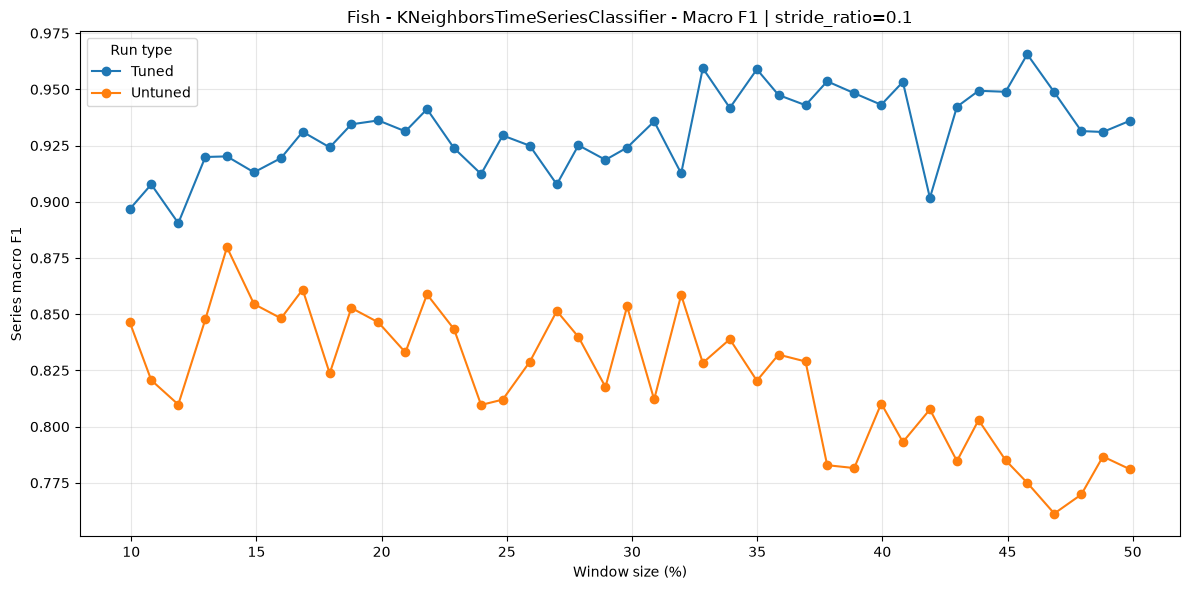

Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/macro_f1_untuned_vs_tuned_stride_0p2.png


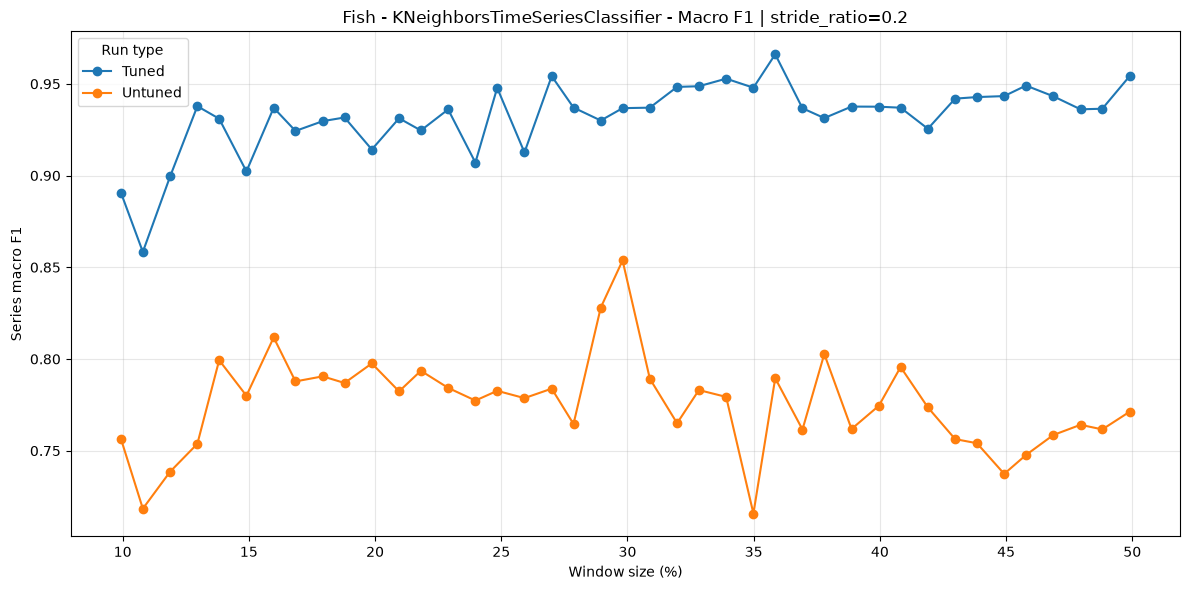

Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/macro_f1_untuned_vs_tuned_stride_0p5.png


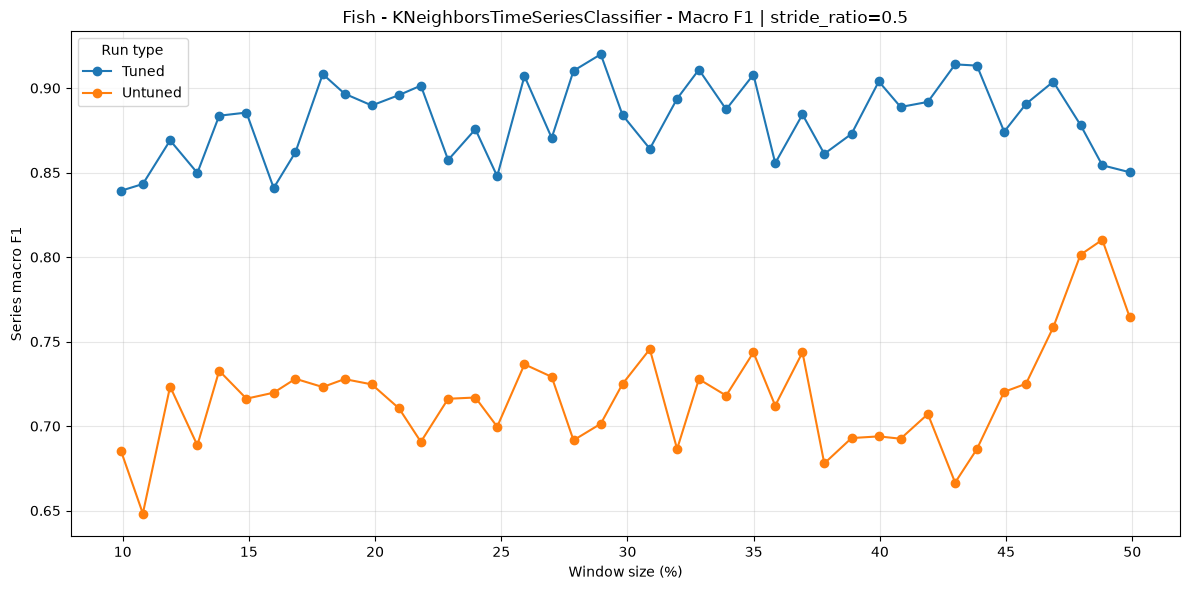

In [11]:
plot_not_tuned = not_tuned_ok.copy()
plot_not_tuned["run_type"] = "Untuned"

plot_tuned = tuned_ok.copy()
plot_tuned["run_type"] = "Tuned"

plot_df = pd.concat([plot_not_tuned, plot_tuned], ignore_index=True)
plot_df = plot_df.sort_values(["stride_ratio", "window_size", "run_type"])

plot_input_file = COMPARISON_DIR / "fish_knn_plot_input_macro_f1.csv"
plot_df.to_csv(plot_input_file, index=False)

print("Saved plot input to:", plot_input_file)

for stride_ratio, group in plot_df.groupby("stride_ratio"):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run_type, run_group in group.groupby("run_type"):
        run_group = run_group.sort_values("window_percentage")
        ax.plot(
            run_group["window_percentage"] * 100,
            run_group["series_macro_f1"],
            marker="o",
            label=run_type,
        )

    ax.set_title(f"Fish - KNeighborsTimeSeriesClassifier - Macro F1 | stride_ratio={stride_ratio}")
    ax.set_xlabel("Window size (%)")
    ax.set_ylabel("Series macro F1")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Run type")

    fig.tight_layout()

    output_file = PLOTS_DIR / f"macro_f1_untuned_vs_tuned_stride_{str(stride_ratio).replace('.', 'p')}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")

    print("Saved:", output_file)
    plt.show()


## 13. Total execution time and per-configuration training times


,phase,total_time_sec,total_time_min,total_time_hour
0,Untuned experiment,36840.417210,614.006953,10.233449
1,Hyperparameter tuning,254026.882691,4233.781378,70.563023
2,Tuned retraining,33556.761652,559.279361,9.321323


,trial_file,n_trials,total_duration_sec
0,results/Fish/tuning/KNeighborsTimeSeriesClassi...,30,4887.992309
1,results/Fish/tuning/KNeighborsTimeSeriesClassi...,30,1320.635660
2,results/Fish/tuning/KNeighborsTimeSeriesClassi...,30,227.743950
3,results/Fish/tuning/KNeighborsTimeSeriesClassi...,30,5023.690514
4,results/Fish/tuning/KNeighborsTimeSeriesClassi...,30,1270.451310


Saved phase time summary to: results/Fish/KNeighborsTimeSeriesClassifier/comparison_10_50/fish_knn_phase_total_times.csv
Saved tuning trial time summary to: results/Fish/KNeighborsTimeSeriesClassifier/comparison_10_50/fish_knn_tuning_trial_total_times.csv
Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/execution_time/total_execution_time_by_phase.png


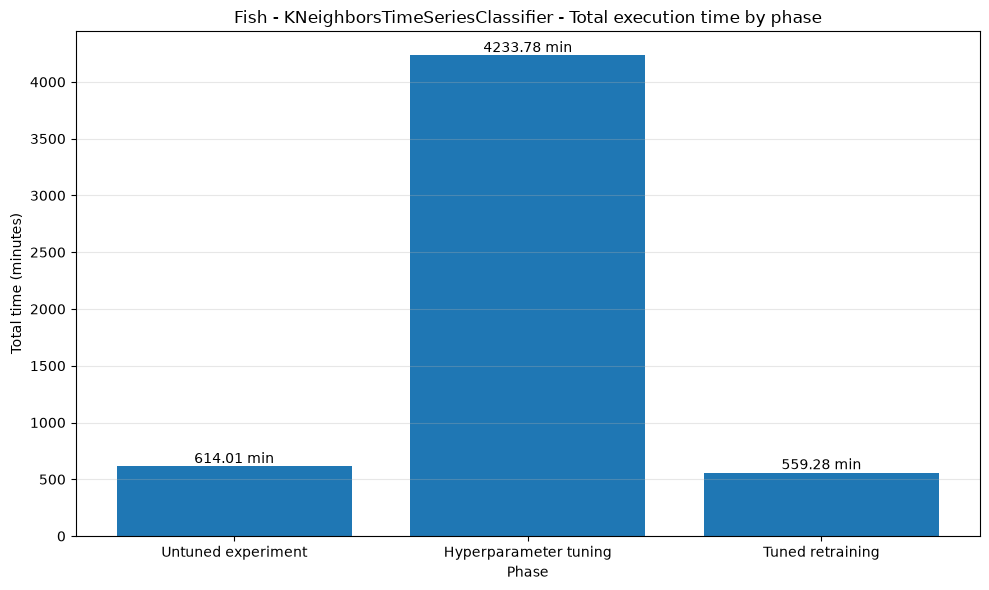

Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/execution_time/untuned_fit_time_by_configuration.png


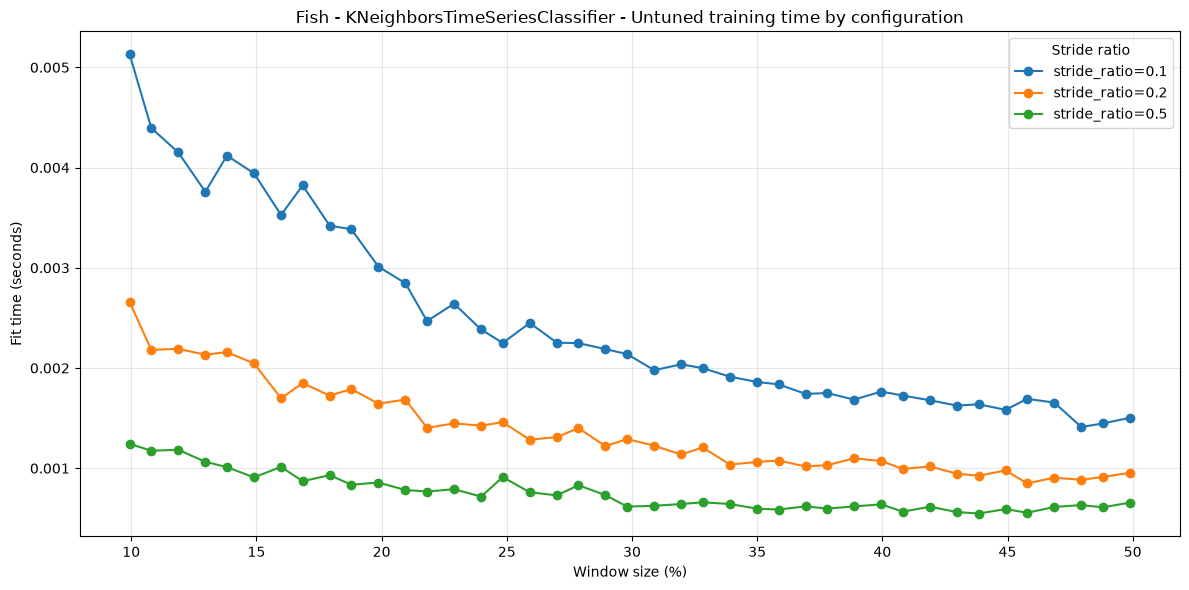

Saved: plots/Fish/KNeighborsTimeSeriesClassifier/macro_f1_10_50/execution_time/tuned_fit_time_by_configuration.png


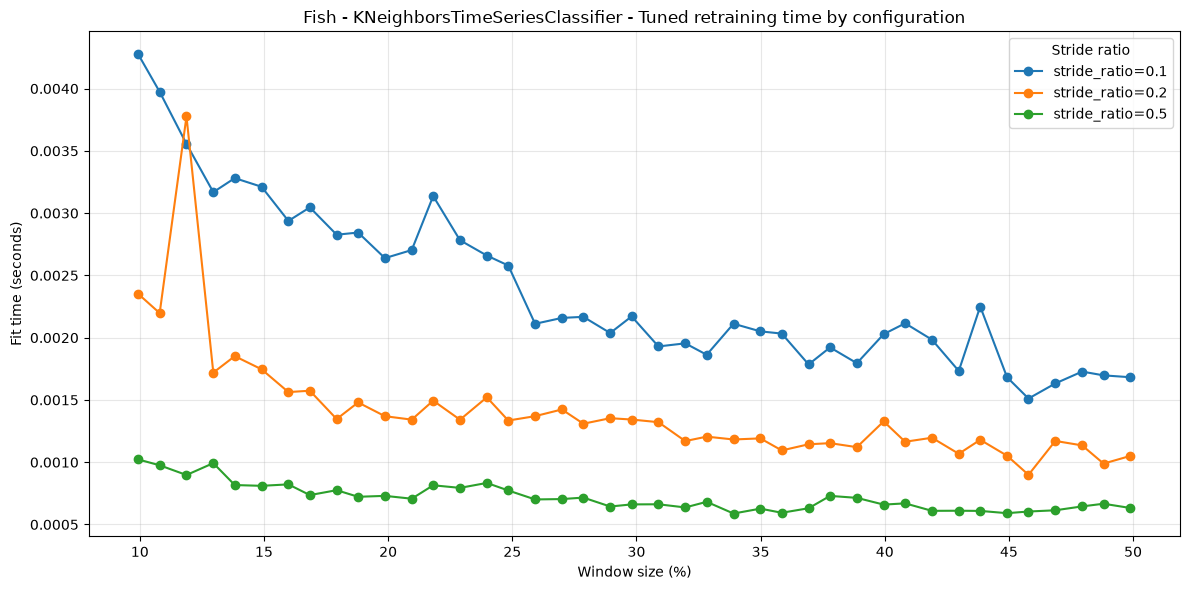

In [12]:
TIME_PLOTS_DIR = PLOTS_DIR / "execution_time"
TIME_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

not_tuned_ok = not_tuned[not_tuned["status"] == "ok"].copy()
tuned_ok = tuned[tuned["status"] == "ok"].copy()

untuned_total_time_sec = not_tuned_ok["total_time_sec"].sum()
tuned_retraining_total_time_sec = tuned_ok["total_time_sec"].sum()

trials_dir = TUNING_DIR / "trials"
trial_files = sorted(trials_dir.glob("*_trials.csv"))

if len(trial_files) == 0:
    raise FileNotFoundError(f"No Optuna trial CSV files found in: {trials_dir}")

tuning_total_time_sec = 0.0
trial_rows = []

for trial_file in trial_files:
    trials_df = pd.read_csv(trial_file)

    if "duration" not in trials_df.columns:
        raise ValueError(
            f"Column 'duration' not found in {trial_file}. "
            "Cannot compute total tuning time."
        )

    durations_sec = pd.to_timedelta(trials_df["duration"]).dt.total_seconds()
    file_total_sec = durations_sec.sum()

    tuning_total_time_sec += file_total_sec

    trial_rows.append({
        "trial_file": str(trial_file),
        "n_trials": len(trials_df),
        "total_duration_sec": file_total_sec,
    })

trial_time_summary = pd.DataFrame(trial_rows)

phase_time_summary = pd.DataFrame([
    {
        "phase": "Untuned experiment",
        "total_time_sec": untuned_total_time_sec,
        "total_time_min": untuned_total_time_sec / 60,
        "total_time_hour": untuned_total_time_sec / 3600,
    },
    {
        "phase": "Hyperparameter tuning",
        "total_time_sec": tuning_total_time_sec,
        "total_time_min": tuning_total_time_sec / 60,
        "total_time_hour": tuning_total_time_sec / 3600,
    },
    {
        "phase": "Tuned retraining",
        "total_time_sec": tuned_retraining_total_time_sec,
        "total_time_min": tuned_retraining_total_time_sec / 60,
        "total_time_hour": tuned_retraining_total_time_sec / 3600,
    },
])

display(phase_time_summary)
display(trial_time_summary.head())

phase_time_file = COMPARISON_DIR / "fish_knn_phase_total_times.csv"
trial_time_file = COMPARISON_DIR / "fish_knn_tuning_trial_total_times.csv"

phase_time_summary.to_csv(phase_time_file, index=False)
trial_time_summary.to_csv(trial_time_file, index=False)

print("Saved phase time summary to:", phase_time_file)
print("Saved tuning trial time summary to:", trial_time_file)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(phase_time_summary["phase"], phase_time_summary["total_time_min"])
ax.set_title("Fish - KNeighborsTimeSeriesClassifier - Total execution time by phase")
ax.set_xlabel("Phase")
ax.set_ylabel("Total time (minutes)")
ax.grid(axis="y", alpha=0.3)

for index, row in phase_time_summary.iterrows():
    ax.text(index, row["total_time_min"], f'{row["total_time_min"]:.2f} min', ha="center", va="bottom")

fig.tight_layout()
output_file = TIME_PLOTS_DIR / "total_execution_time_by_phase.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print("Saved:", output_file)
plt.show()

untuned_plot = not_tuned_ok.sort_values(["stride_ratio", "window_percentage"]).copy()
fig, ax = plt.subplots(figsize=(12, 6))

for stride_ratio, group in untuned_plot.groupby("stride_ratio"):
    group = group.sort_values("window_percentage")
    ax.plot(group["window_percentage"] * 100, group["fit_time_sec"], marker="o", label=f"stride_ratio={stride_ratio}")

ax.set_title("Fish - KNeighborsTimeSeriesClassifier - Untuned training time by configuration")
ax.set_xlabel("Window size (%)")
ax.set_ylabel("Fit time (seconds)")
ax.grid(True, alpha=0.3)
ax.legend(title="Stride ratio")
fig.tight_layout()
output_file = TIME_PLOTS_DIR / "untuned_fit_time_by_configuration.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print("Saved:", output_file)
plt.show()

tuned_plot = tuned_ok.sort_values(["stride_ratio", "window_percentage"]).copy()
fig, ax = plt.subplots(figsize=(12, 6))

for stride_ratio, group in tuned_plot.groupby("stride_ratio"):
    group = group.sort_values("window_percentage")
    ax.plot(group["window_percentage"] * 100, group["fit_time_sec"], marker="o", label=f"stride_ratio={stride_ratio}")

ax.set_title("Fish - KNeighborsTimeSeriesClassifier - Tuned retraining time by configuration")
ax.set_xlabel("Window size (%)")
ax.set_ylabel("Fit time (seconds)")
ax.grid(True, alpha=0.3)
ax.legend(title="Stride ratio")
fig.tight_layout()
output_file = TIME_PLOTS_DIR / "tuned_fit_time_by_configuration.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print("Saved:", output_file)
plt.show()


## 14. Final summary


In [13]:
summary = comparison.sort_values("tuned_series_macro_f1", ascending=False).copy()

display(summary[[
    "window_size",
    "window_percentage",
    "stride_ratio",
    "not_tuned_series_macro_f1",
    "tuned_series_macro_f1",
    "delta_series_macro_f1",
    "classifier_hyperparameters",
]].head(20))

best_row = summary.iloc[0]

print("Best tuned configuration")
print("------------------------")
print("window_size:", best_row["window_size"])
print("window_percentage:", best_row["window_percentage"])
print("stride_ratio:", best_row["stride_ratio"])
print("untuned macro F1:", best_row["not_tuned_series_macro_f1"])
print("tuned macro F1:", best_row["tuned_series_macro_f1"])
print("delta macro F1:", best_row["delta_series_macro_f1"])
print("hyperparameters:", best_row["classifier_hyperparameters"])


,window_size,window_percentage,stride_ratio,not_tuned_series_macro_f1,tuned_series_macro_f1,delta_series_macro_f1,classifier_hyperparameters
79,166,0.358531,0.2,0.789502,0.966098,0.176595,"{""distance"": ""ddtw"", ""n_neighbors"": 9, ""weight..."
108,212,0.457883,0.1,0.775033,0.965595,0.190562,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
69,152,0.328294,0.1,0.828355,0.959404,0.131049,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight..."
75,162,0.349892,0.1,0.820418,0.958921,0.138503,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
52,125,0.269978,0.2,0.783840,0.954182,0.170342,"{""distance"": ""ddtw"", ""n_neighbors"": 7, ""weight..."
121,231,0.498920,0.2,0.771229,0.954148,0.182918,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
84,175,0.377970,0.1,0.782859,0.953581,0.170722,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight..."
93,189,0.408207,0.1,0.793162,0.953313,0.160151,"{""distance"": ""ddtw"", ""n_neighbors"": 5, ""weight..."
73,157,0.339093,0.2,0.779338,0.952816,0.173478,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."
102,203,0.438445,0.1,0.802927,0.949366,0.146439,"{""distance"": ""ddtw"", ""n_neighbors"": 3, ""weight..."


Best tuned configuration
------------------------
window_size: 166
window_percentage: 0.3585313174946004
stride_ratio: 0.2
untuned macro F1: 0.789502367551148
tuned macro F1: 0.9660977469006686
delta macro F1: 0.17659537934952063
hyperparameters: {"distance": "ddtw", "n_neighbors": 9, "weights": "distance"}
